<a href="https://colab.research.google.com/github/SRILAKSHMI-30/Customer_shopping_behaviour/blob/main/Custome_shopping_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
df=pd.read_csv("customer_shopping_behavior.csv")
df

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,NaN,0,Same Day,1,Yes,Cash on Delivery,4,Not Returned,0,Fortnightly
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,NaN,Clothing,Shirt,...,NaN,0,NaN,0,No,UPI,5,Not Returned,0,Fortnightly
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,NaN,0,Standard,7,Yes,UPI,3,Not Returned,0,Rarely
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,NaN,0,Standard,6,Yes,Net Banking,4,Not Returned,0,Fortnightly
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,NaN,99,Express,2,No,Debit Card,4,Not Returned,0,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN509420,CUST102996,2024-12-31,30,Male,Bangalore,Online,Flipkart,Clothing,Trousers,...,End of Season Sale,199,Express,4,No,Debit Card,3,Not Returned,8,Fortnightly
9996,TXN500945,CUST100273,2024-12-31,58,Female,Kolkata,Online,Flipkart,Clothing,Saree,...,End of Season Sale,149,Express,4,No,UPI,5,Not Returned,1,Monthly
9997,TXN501737,CUST100566,2024-12-31,27,Female,Chennai,Online,Myntra,Clothing,Trousers,...,End of Season Sale,0,Standard,8,No,UPI,4,Not Returned,5,Weekly
9998,TXN506133,CUST102017,2024-12-31,48,Male,Bangalore,Online,Myntra,Footwear,Sandals,...,End of Season Sale,99,Standard,5,No,UPI,4,Not Returned,1,Monthly


In [19]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Age,0
Gender,0
Location,0
Online/Offline,0
Online Store,0
Category,0
Item Purchased,0
Brand,0


In [5]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Purchase Date,object
Age,int64
Gender,object
Location,object
Online/Offline,object
Online Store,object
Category,object
Item Purchased,object


In [20]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Age', 'Gender', 'Location',
       'Online/Offline', 'Online Store', 'Category', 'Item Purchased', 'Brand',
       'Color', 'Size', 'Quantity', 'Purchase Amount (₹)', 'Discount (%)',
       'Festival/Sale', 'Shipping Charge (₹)', 'Delivery Speed',
       'Delivery Time (Days)', 'Subscription Status', 'Payment Method',
       'Review Rating', 'Return Status', 'Previous Purchases',
       'Frequency of Purchases', 'Month', 'Month_Num', 'Purchase_Year',
       'Purchase_Month', 'Purchase_Day'],
      dtype='object')

In [68]:
df["Size"].unique()

array(['L', 'M', 'Free Size', '11', '8', '9', '7', '10', '6'],
      dtype=object)

In [69]:
df["Online Store"].unique()

array(['Flipkart', 'Near_by_shop', 'Myntra', 'Amazon', 'Ajio', 'Shein',
       'Meesho'], dtype=object)

In [70]:
df["Delivery Speed"].unique()

array(['Same Day', 'Standard', 'Express'], dtype=object)

In [71]:
df["Festival/Sale"].unique()

array(['Republic Day Sales', 'Valentine’s Day Sales', 'Holi Sales',
       'Akshaya Tritiya Sales', 'Summer Sale', 'End of Season Sale',
       'Mid-Year Mega Sales', 'Independence Day Sales', 'Navratri Sales',
       'Diwali Sales', 'Dhanteras & Diwali Continuation',
       'Christmas & Year-End Clearance'], dtype=object)

In [62]:
df["Size"]=df.groupby(["Age","Category"])["Size"].transform(lambda x:x.mode()[0])

In [63]:
df["Purchase Date"]=pd.to_datetime(df["Purchase Date"])
df["Month"] = df["Purchase Date"].dt.month_name()   # gives 'January', 'February', etc.
# or
df["Month_Num"] = df["Purchase Date"].dt.month      # gives 1, 2, 3...


In [64]:
festival_sales = {
    "January": "Republic Day Sales",
    "February": "Valentine’s Day Sales",
    "March": "Holi Sales",
    "April": "Akshaya Tritiya Sales",
    "May": "Summer Sale",
    "June": "End of Season Sale",
    "July": "Mid-Year Mega Sales",
    "August": "Independence Day Sales",
    "September": "Navratri Sales",
    "October": "Diwali Sales",
    "November": "Dhanteras & Diwali Continuation",
    "December": "Christmas & Year-End Clearance"
}
df["Festival/Sale"] = df["Month"].map(festival_sales)


In [65]:
# Create a temporary column with delivery type based on conditions
conditions = [
    df["Delivery Time (Days)"] == 0,
    (df["Delivery Time (Days)"] > 0) & (df["Delivery Time (Days)"] <= 5),
    df["Delivery Time (Days)"] > 5
]

choices = ["Same Day", "Express", "Standard"]

temp_delivery = np.select(conditions, choices, default=None)

# Fill only NaN values in Delivery column
df["Delivery Speed"] = df["Delivery Speed"].fillna(pd.Series(temp_delivery))


In [67]:
df["Online Store"]=df["Online Store"].fillna("Near_by_shop")

In [66]:
# Select only object (string) columns
object_cols = df.select_dtypes(include=["object"])
object_cols.columns


Index(['Transaction ID', 'Customer ID', 'Gender', 'Location', 'Online/Offline',
       'Online Store', 'Category', 'Item Purchased', 'Brand', 'Color', 'Size',
       'Festival/Sale', 'Delivery Speed', 'Subscription Status',
       'Payment Method', 'Return Status', 'Frequency of Purchases', 'Month'],
      dtype='object')

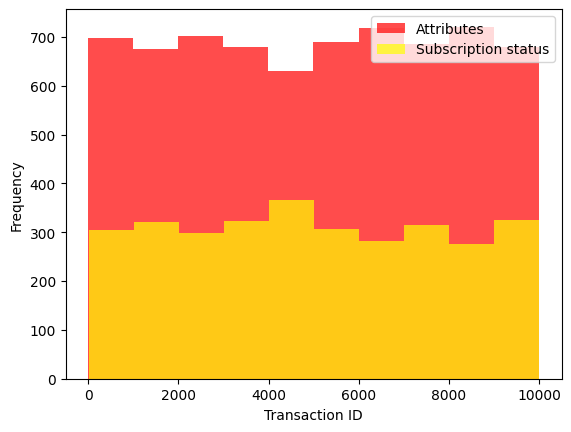

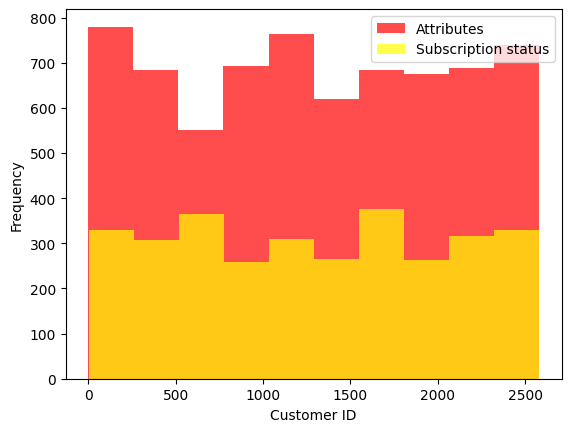

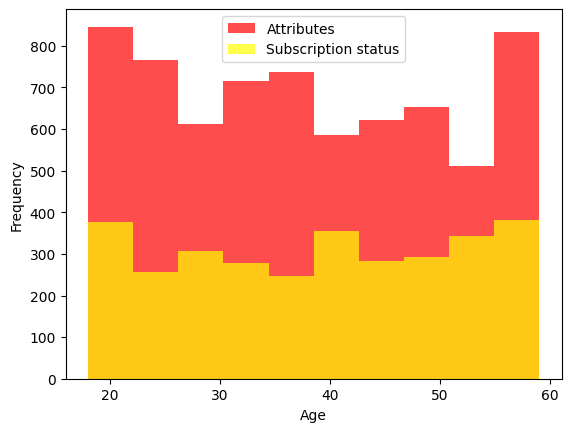

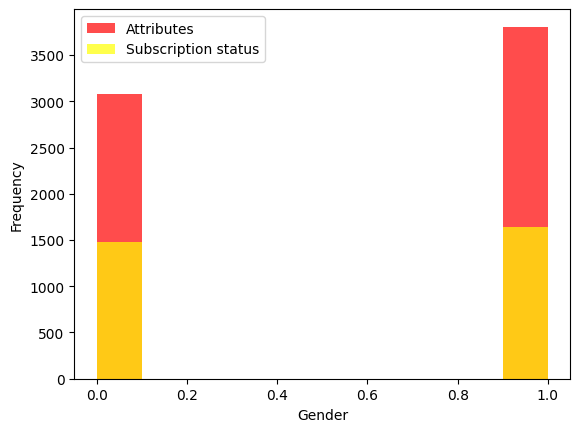

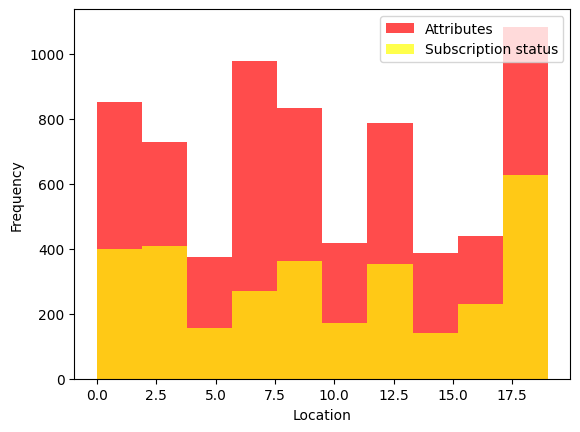

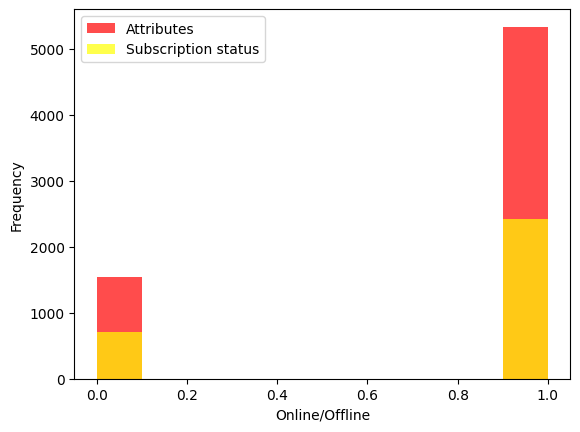

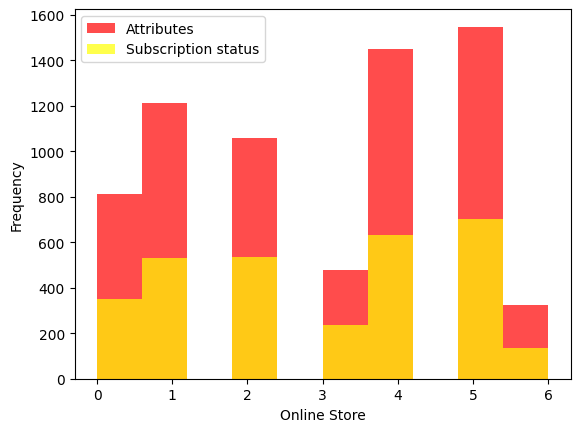

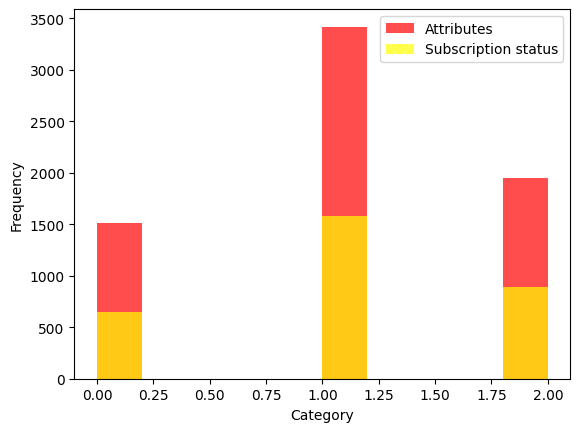

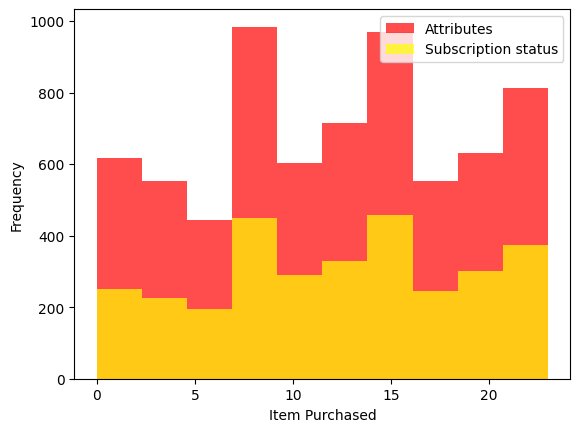

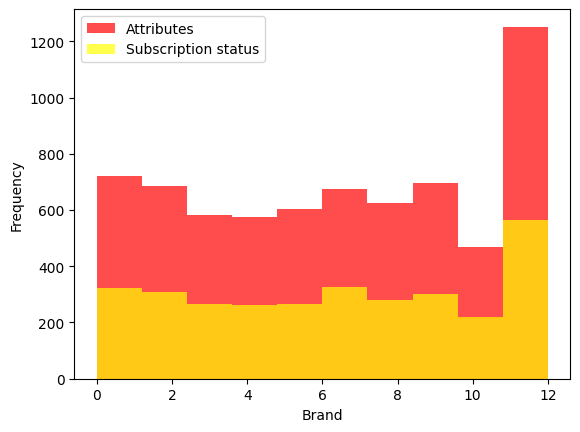

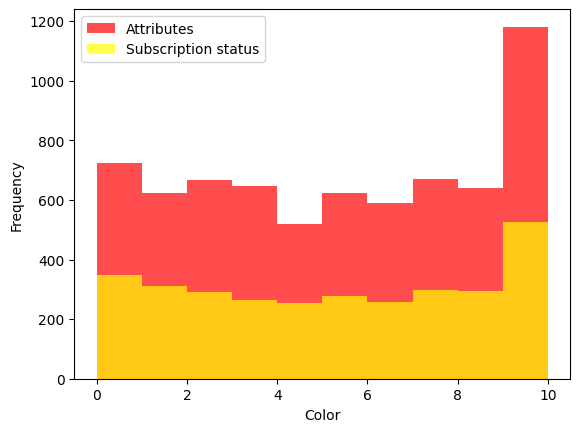

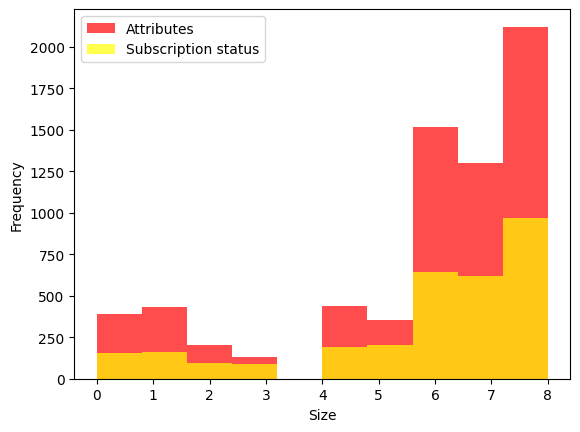

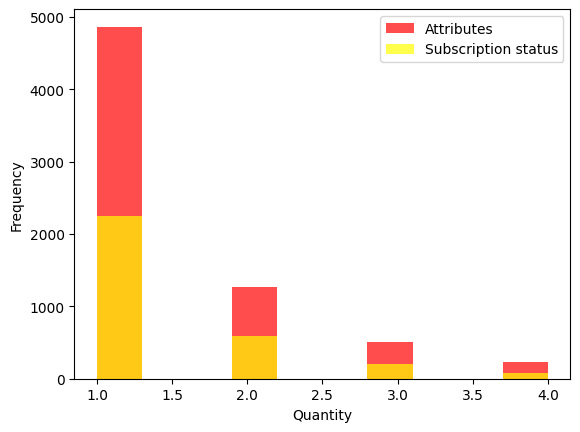

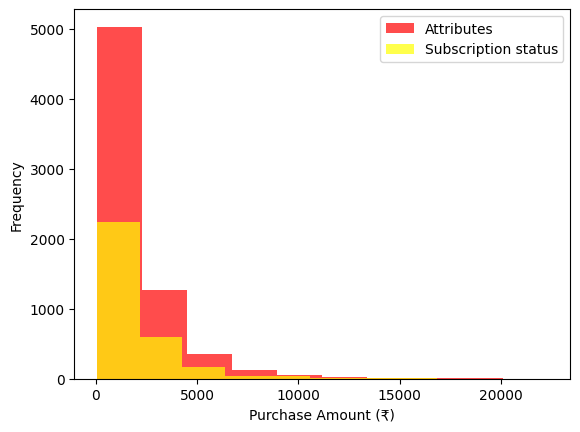

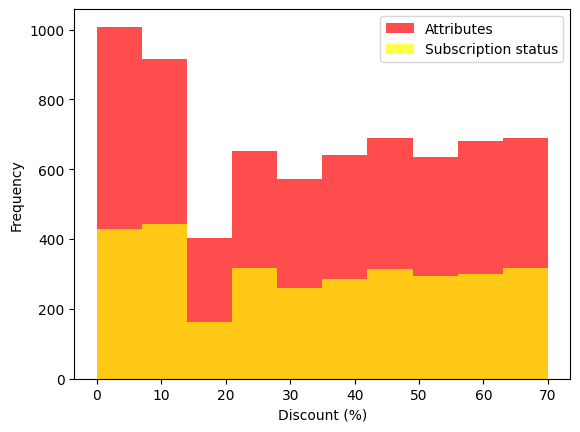

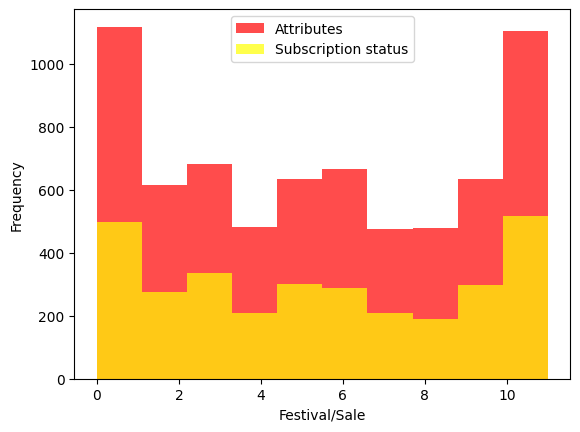

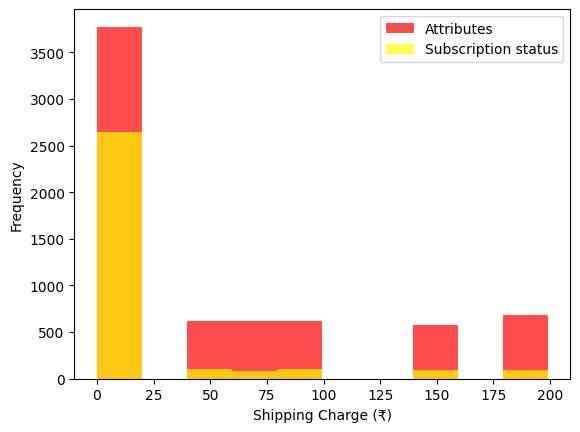

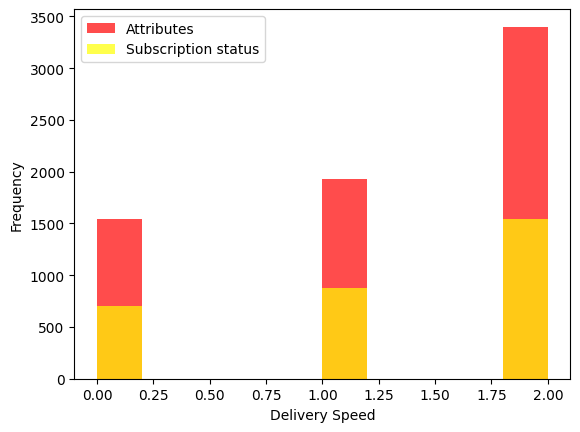

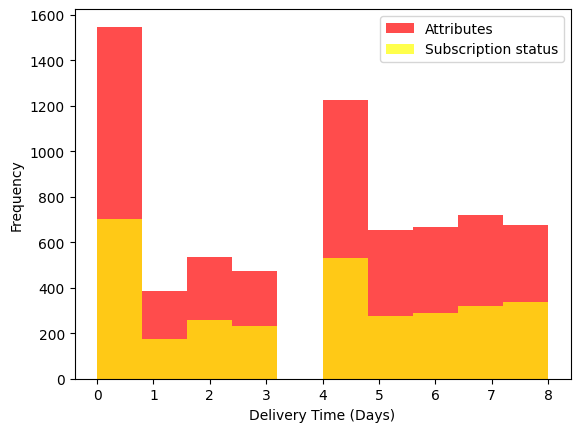

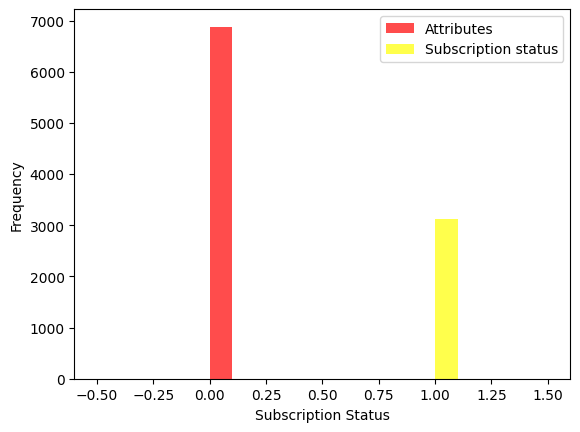

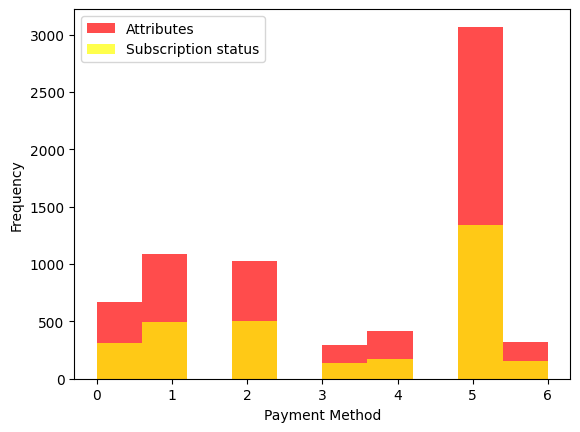

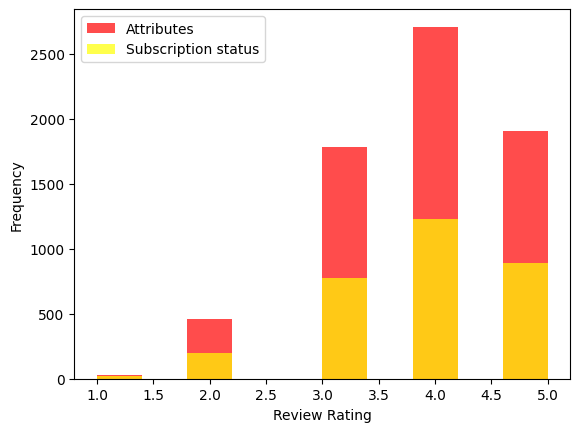

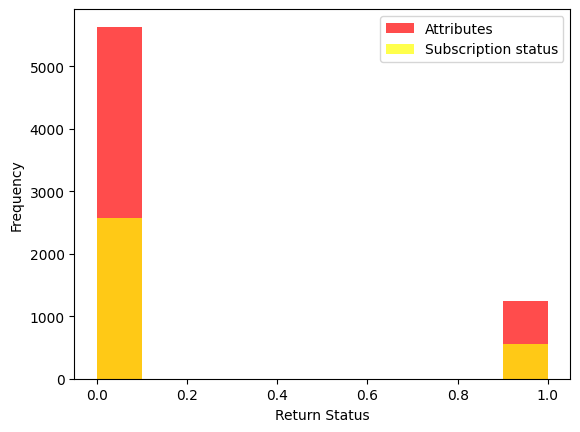

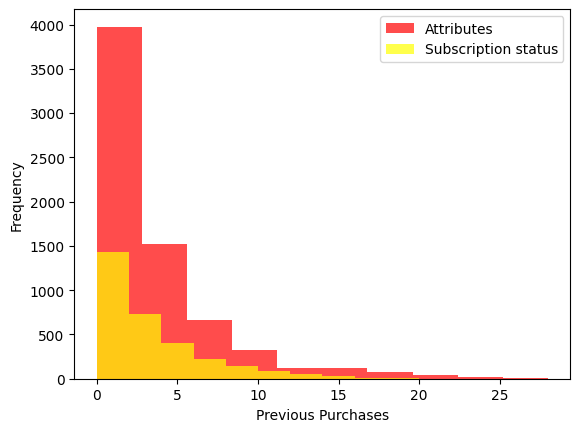

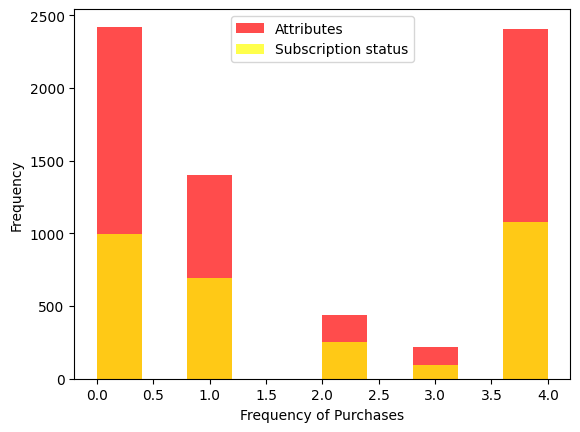

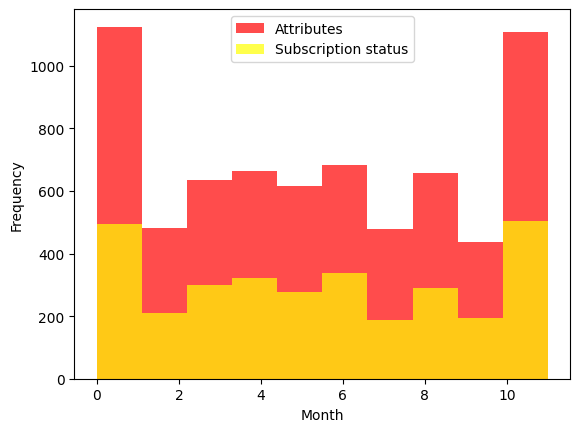

In [58]:
for label in df.columns:
    # Skip non-numeric columns to avoid errors
    if df[label].dtype in ['int64', 'float64']:
        plt.hist(df[df["Subscription Status"] == 0][label],color='red', label='Attributes', alpha=0.7)
        plt.hist(df[df["Subscription Status"] == 1][label],color='yellow', label='Subscription status', alpha=0.7)
        plt.xlabel(label)
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

Standard scaler & label - encoder

In [56]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Encode categorical columns
string_cols = ['Transaction ID', 'Customer ID', 'Gender', 'Location', 'Online/Offline',
               'Online Store', 'Category', 'Item Purchased', 'Brand', 'Color', 'Size',
               'Festival/Sale', 'Delivery Speed', 'Payment Method', 'Return Status',
               'Frequency of Purchases']

for col in string_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Step 2: Features and target
X = df.drop("Subscription Status", axis=1)
y = df["Subscription Status"].replace({"Yes": 1, "No": 0})

# Step 3: Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Logistic Regression

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
lr=LogisticRegression(max_iter=5000, solver="saga")
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification:",classification_report(y_test,y_pred, zero_division=0))

Accuracy: 0.684

Confusion Matrix:
 [[1368    0]
 [ 632    0]]
Classification:               precision    recall  f1-score   support

           0       0.68      1.00      0.81      1368
           1       0.00      0.00      0.00       632

    accuracy                           0.68      2000
   macro avg       0.34      0.50      0.41      2000
weighted avg       0.47      0.68      0.56      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
y_train.value_counts()

,count
Subscription Status,
0,5513
1,2487


Naive Bayes

In [44]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
naive_bayes=GaussianNB()
naive_bayes.fit(X_train,y_train)
y_pred=naive_bayes.predict(X_test)
print("Classification:",classification_report(y_test,y_pred))

Classification:               precision    recall  f1-score   support

           0       0.75      0.75      0.75      1368
           1       0.45      0.45      0.45       632

    accuracy                           0.65      2000
   macro avg       0.60      0.60      0.60      2000
weighted avg       0.65      0.65      0.65      2000



Random Forest Classifier

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
rfc=RandomForestClassifier(n_estimators=350)
rfc.fit(X_train,y_train)
y_pred=rfc.predict(X_test)
print("Classification:",classification_report(y_test,y_pred))

Classification:               precision    recall  f1-score   support

           0       0.73      0.95      0.83      1368
           1       0.69      0.26      0.37       632

    accuracy                           0.73      2000
   macro avg       0.71      0.60      0.60      2000
weighted avg       0.72      0.73      0.68      2000



Support Vector Classifier

In [72]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
svc=SVC()
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1368
           1       0.00      0.00      0.00       632

    accuracy                           0.68      2000
   macro avg       0.34      0.50      0.41      2000
weighted avg       0.47      0.68      0.56      2000



K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print("Classification:",classification_report(y_test,y_pred))

Classification:               precision    recall  f1-score   support

           0       0.72      0.84      0.78      1368
           1       0.46      0.29      0.36       632

    accuracy                           0.67      2000
   macro avg       0.59      0.57      0.57      2000
weighted avg       0.64      0.67      0.64      2000



Decision Tree Classifier

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77      1368
           1       0.51      0.54      0.52       632

    accuracy                           0.69      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.70      0.69      0.69      2000



Gradient Boosting Classifier

In [48]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2487, number of negative: 5513
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1121
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310875 -> initscore=-0.796032
[LightGBM] [Info] Start training from score -0.796032
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.94      0.87      1368
           1       0.81      0.53      0.64       632

    accuracy                           0.81      2000
   macro avg       0.81      0.74      0.76      2000
weighted avg       0.81      0.81      0.80      2000



In [49]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
lgbm = LGBMClassifier(random_state=42)
param_dist = {
    "n_estimators": np.arange(50, 301, 50),
    "max_depth": [ -1, 5, 10, 20 ],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [31, 50, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)
y_pred = random_search.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2487, number of negative: 5513
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1121
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310875 -> initscore=-0.796032
[LightGBM] [Info] Start training from score -0.796032
Best Parameters: {'subsample': 0.8, 'num_leaves': 100, 'n_estimators': np.int64(200), 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90      1368
           1       0.86      0.66      0.74       632

    accuracy                           0.86      2000
   macro avg       0.86      0.80    

In [50]:
df.to_excel("customer_behavoiur.xlsx", index=False)